<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula10a_%C3%A1rvore_de_decis%C3%A3o_com_atributos_num%C3%A9ricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_iris

dataset = load_iris()
X = dataset.data[:,2:]
y = dataset.target
feature_names = dataset.feature_names[2:]
target_names = dataset.target_names

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

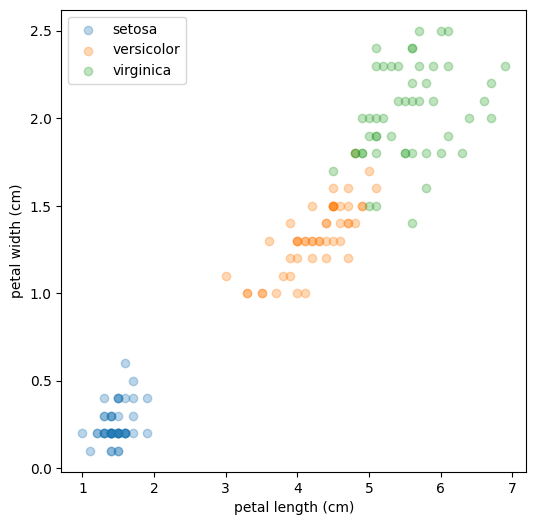

In [5]:
from matplotlib import pyplot as plt

def plotDataset(X, y):
  plt.figure(figsize=(6,6))
  for i in range(len(set(y))):
    plt.scatter(X[y==i,0],X[y==i,1], label=target_names[i], alpha=0.3)
  plt.xlabel(feature_names[0])
  plt.ylabel(feature_names[1])
  plt.legend()

plotDataset(X, y)
plt.show()

In [6]:
import numpy as np

def most_fequent(a):
  labels, counts = np.unique(a, return_counts=True)
  return labels[np.argmax(counts)]

tr_labels, tr_counts = np.unique(y_train, return_counts=True)
print(f"Train labels: {tr_labels}")
print(f"Train counts: {tr_counts}")
print(f"train most frequent: {most_fequent(y_train)}")
te_labels, te_counts = np.unique(y_test, return_counts=True)
print(f"Test labels: {te_labels}")
print(f"Test counts: {te_counts}")
print(f"test most frequent: {most_fequent(y_test)}")

Train labels: [0 1 2]
Train counts: [38 37 45]
train most frequent: 2
Test labels: [0 1 2]
Test counts: [12 13  5]
test most frequent: 1


In [14]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class ZeroR(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.answer = most_fequent(y)

  def predict(self, X):
    return [self.answer]*X.shape[0]

zeroR = ZeroR()
zeroR.fit(X_train, y_train)
y_pred = zeroR.predict(X_test)
accuracy_score(y_test, y_pred)

0.16666666666666666

In [8]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.feature = np.random.randint(X.shape[1])
    self.value = np.random.choice(X[:,self.feature])
    lessers = X[:,self.feature] < self.value
    if sum(lessers) == 0 or sum(~lessers) == 0:
      self.answer = most_fequent(y)
    else:
      self.lessers = DecisionTree()
      self.lessers.fit(X[lessers], y[lessers])
      self.not_lessers = DecisionTree()
      self.not_lessers.fit(X[~lessers], y[~lessers])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      lessers = X[:,self.feature] < self.value
      return np.where(lessers, self.lessers.predict(X), self.not_lessers.predict(X))

tree = DecisionTree()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8666666666666667

0.9333333333333333


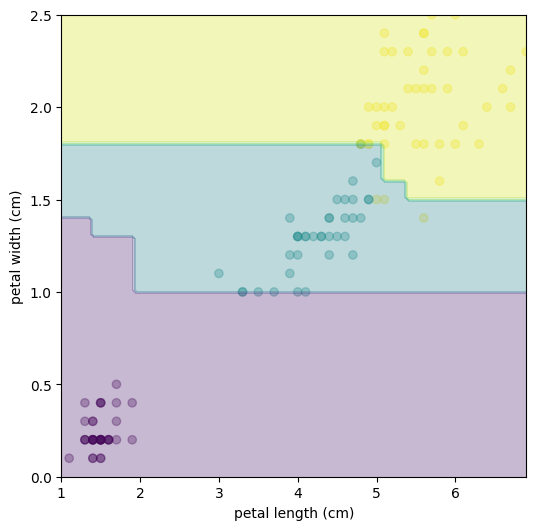

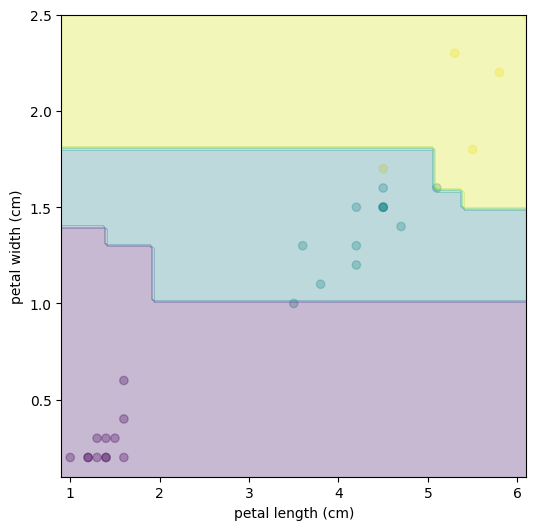

In [9]:
def defineAxes(X):
  off_set = 0.1
  x_min, x_max = X[:, 0].min() - off_set, X[:, 0].max()
  y_min, y_max = X[:, 1].min() - off_set, X[:, 1].max()
  return x_min, x_max, y_min, y_max

def plotPredictions(model, X, y):
  x_min, x_max, y_min, y_max = defineAxes(X)
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)

def plotDecisionBoundary(model, X, y):
  plt.figure(figsize=(6,6))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.3)
  plotPredictions(model, X, y)
  plt.xlabel(feature_names[0])
  plt.ylabel(feature_names[1])
  plt.show()

model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDecisionBoundary(model, X_train, y_train)
plotDecisionBoundary(model, X_test, y_test)

In [10]:
def gini(y):
  labels, counts = np.unique(y, return_counts=True)
  p = counts/sum(counts)
  return 1-sum(p**2)

def entropy(y):
  labels, counts = np.unique(y, return_counts=True)
  p = counts/sum(counts)
  return -sum(p*np.log2(p))

print(gini(y_train))
print(entropy(y_train))

0.6640277777777778
1.5793538508254956


In [11]:
print(gini(np.ones(100)))

0.0


In [12]:
print(gini(np.arange(100)))

0.99


In [20]:
def imputity_value(x, y, value, impurity_function=gini):
  lessers = x < value
  lessers_impurity = impurity_function(y[lessers])
  not_lessers_impurity = impurity_function(y[~lessers])
  return (sum(lessers)*lessers_impurity + sum(~lessers)*not_lessers_impurity)/len(y)

print(imputity_value(X_train[:,0], y_train, 5))

0.3829268292682927


In [26]:
def best_split(x, y, impurity_function=gini):
  best_value = 0
  best_impurity = np.inf
  x_sorted = np.sort(x)
  for i in range(len(x)-1):
    value = (x_sorted[i]+x_sorted[i+1])/2
    impurity = imputity_value(x, y, value, impurity_function)
    if impurity < best_impurity:
      best_value = value
      best_impurity = impurity
  return best_value, best_impurity

print(best_split(X_train[:,0], y_train))

(np.float64(2.45), np.float64(0.3384146341463414))


In [27]:
def best_feature(X, y, impurity_function=gini):
  best_feature = 0
  best_value = 0
  best_impurity = np.inf
  for i in range(X.shape[1]):
    value, impurity = best_split(X[:,i], y, impurity_function)
    if impurity < best_impurity:
      best_feature = i
      best_value = value
      best_impurity = impurity
  return best_feature, best_value, best_impurity

print(best_feature(X_train, y_train))

(0, np.float64(2.45), np.float64(0.3384146341463414))


In [31]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(X, y)
    lessers = X[:,self.feature] < self.value
    if sum(lessers) == 0 or sum(~lessers) == 0:
      self.answer = most_fequent(y)
    else:
      self.lessers = DecisionTree()
      self.lessers.fit(X[lessers], y[lessers])
      self.not_lessers = DecisionTree()
      self.not_lessers.fit(X[~lessers], y[~lessers])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      lessers = X[:,self.feature] < self.value
      return np.where(lessers, self.lessers.predict(X), self.not_lessers.predict(X))

tree = DecisionTree()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.9333333333333333

0.9333333333333333


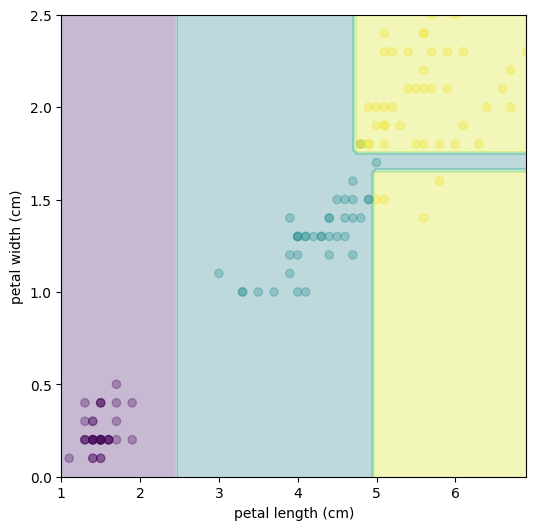

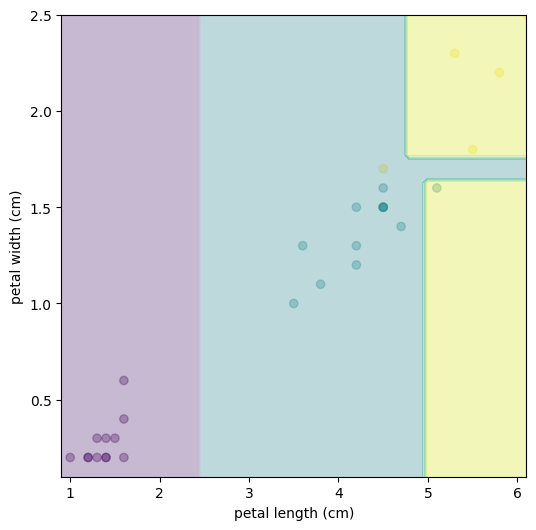

In [32]:
model = DecisionTree()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
plotDecisionBoundary(model, X_train, y_train)
plotDecisionBoundary(model, X_test, y_test)

In [38]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(5, shuffle=True)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(scores)
print(scores.mean())

[0.93333333 0.96666667 0.93333333 0.93333333 0.93333333]
0.9400000000000001


In [59]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def __init__(self, impurity_function=gini, min_samples_split=1, max_depth=100):
    self.impurity_function = impurity_function
    self.min_samples_split = min_samples_split
    self.max_depth = max_depth

  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(X, y, self.impurity_function)
    lessers = X[:,self.feature] < self.value
    if sum(lessers) < self.min_samples_split or sum(~lessers) < self.min_samples_split or self.max_depth <= 0:
      self.answer = most_fequent(y)
    else:
      self.lessers = DecisionTree(self.impurity_function, self.min_samples_split, self.max_depth-1)
      self.lessers.fit(X[lessers], y[lessers])
      self.not_lessers = DecisionTree(self.impurity_function, self.min_samples_split, self.max_depth-1)
      self.not_lessers.fit(X[~lessers], y[~lessers])
    return self
  def predict(self, X):
    if hasattr(self, 'answer'):
      return [self.answer]*X.shape[0]
    else:
      lessers = X[:,self.feature] < self.value
      return np.where(lessers, self.lessers.predict(X), self.not_lessers.predict(X))

tree = DecisionTree(min_samples_split=1, max_depth=2)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.9333333333333333

In [61]:
model = DecisionTree(min_samples_split=10, max_depth=5)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(scores)
print(scores.mean())

[0.86666667 0.9        0.93333333 1.         1.        ]
0.9400000000000001


In [63]:
!pip install optuna -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.1 MB/s eta 0:00:00


In [66]:
import optuna

def objective(trial):
  min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
  max_depth = trial.suggest_int('max_depth', 1, 10)

  model = DecisionTree(min_samples_split=min_samples_split, max_depth=max_depth)

  cv = KFold(5, shuffle=True)
  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
  return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best trial value: {study.best_value}")
print(f"Best trial hyperparameters: {study.best_params}")

print("Final evaluation")
model = DecisionTree(**study.best_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

[I 2026-09-17 15:42:08,480] A new study created in memory with name: no-name-881dfed9-7192-4d6b-960a-826a8aa39d41
[I 2026-09-17 15:42:08,671] Trial 0 finished with value: 0.6916666666666667 and parameters: {'min_samples_split': 14, 'max_depth': 1}. Best is trial 0 with value: 0.6916666666666667.
[I 2026-09-17 15:42:08,924] Trial 1 finished with value: 0.9166666666666666 and parameters: {'min_samples_split': 7, 'max_depth': 6}. Best is trial 1 with value: 0.9166666666666666.
[I 2026-09-17 15:42:09,202] Trial 2 finished with value: 0.825 and parameters: {'min_samples_split': 20, 'max_depth': 2}. Best is trial 1 with value: 0.9166666666666666.
[I 2026-09-17 15:42:09,514] Trial 3 finished with value: 0.9 and parameters: {'min_samples_split': 6, 'max_depth': 2}. Best is trial 1 with value: 0.9166666666666666.
[I 2026-09-17 15:42:09,756] Trial 4 finished with value: 0.925 and parameters: {'min_samples_split': 9, 'max_depth': 7}. Best is trial 4 with value: 0.925.
[I 2026-09-17 15:42:10,093] 

Best trial value: 0.9833333333333332
Best trial hyperparameters: {'min_samples_split': 2, 'max_depth': 4}
Final evaluation
0.9333333333333333


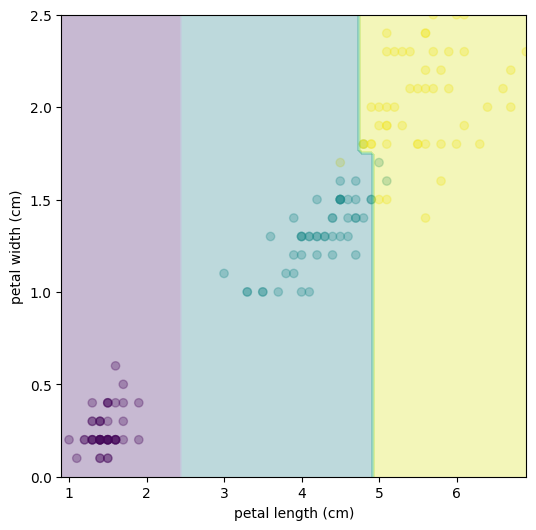

In [67]:
plotDecisionBoundary(model, X, y)


In [68]:
class AutoTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    def objective(trial):
      min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
      max_depth = trial.suggest_int('max_depth', 1, 10)
      model = DecisionTree(min_samples_split=min_samples_split, max_depth=max_depth)
      cv = KFold(5, shuffle=True)
      scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
      return scores.mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)
    self.tree = DecisionTree(**study.best_params)
    self.tree.fit(X, y)
    return self

  def predict(self, X):
    return self.tree.predict(X)

model = AutoTree()
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(scores)
print(scores.mean())

[I 2026-09-17 15:46:58,891] A new study created in memory with name: no-name-63e86265-6fc0-4ff8-b44a-6e18b3f5f4cc
[I 2026-09-17 15:46:59,377] Trial 0 finished with value: 0.6249999999999999 and parameters: {'min_samples_split': 10, 'max_depth': 1}. Best is trial 0 with value: 0.6249999999999999.
[I 2026-09-17 15:46:59,935] Trial 1 finished with value: 0.9333333333333332 and parameters: {'min_samples_split': 18, 'max_depth': 3}. Best is trial 1 with value: 0.9333333333333332.
[I 2026-09-17 15:47:00,587] Trial 2 finished with value: 0.9333333333333332 and parameters: {'min_samples_split': 11, 'max_depth': 10}. Best is trial 1 with value: 0.9333333333333332.
[I 2026-09-17 15:47:01,199] Trial 3 finished with value: 0.925 and parameters: {'min_samples_split': 12, 'max_depth': 7}. Best is trial 1 with value: 0.9333333333333332.
[I 2026-09-17 15:47:01,937] Trial 4 finished with value: 0.9166666666666666 and parameters: {'min_samples_split': 16, 'max_depth': 9}. Best is trial 1 with value: 0.9

[0.93333333 0.93333333 1.         0.96666667 0.96666667]
0.96


In [69]:
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(scores)
print(scores.mean())

[I 2026-09-17 15:47:46,943] A new study created in memory with name: no-name-4751a4b9-f964-4b45-a6aa-1cdda70bb150
[I 2026-09-17 15:47:48,382] Trial 0 finished with value: 0.9 and parameters: {'min_samples_split': 15, 'max_depth': 5}. Best is trial 0 with value: 0.9.
[I 2026-09-17 15:47:49,330] Trial 1 finished with value: 0.925 and parameters: {'min_samples_split': 19, 'max_depth': 2}. Best is trial 1 with value: 0.925.
[I 2026-09-17 15:47:50,097] Trial 2 finished with value: 0.9166666666666666 and parameters: {'min_samples_split': 2, 'max_depth': 2}. Best is trial 1 with value: 0.925.
[I 2026-09-17 15:47:50,856] Trial 3 finished with value: 0.9333333333333332 and parameters: {'min_samples_split': 14, 'max_depth': 6}. Best is trial 3 with value: 0.9333333333333332.
[I 2026-09-17 15:47:51,611] Trial 4 finished with value: 0.9416666666666667 and parameters: {'min_samples_split': 5, 'max_depth': 3}. Best is trial 4 with value: 0.9416666666666667.
[I 2026-09-17 15:47:52,355] Trial 5 finish

[0.93333333 0.96666667 0.96666667 0.93333333 0.9       ]
0.9400000000000001
